<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_objetivo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Detallado del Objetivo Específico 3: Incidencia de Datos Históricos de Precios en Modelos Supervisados

Este notebook presenta un análisis exhaustivo del Objetivo Específico 3 de la tesis "Uso de modelos supervisados por analistas financieros en la predicción de precios de acciones de Google y Amazon". El objetivo se centra en "Evaluar la incidencia de los datos históricos de precios en la precisión de los modelos supervisados para la predicción de precios de acciones financieras".

Se explorará el dataset proporcionado, se implementarán modelos de Machine Learning (Random Forest y Gradient Boosting) y se generarán pronósticos bajo diferentes escenarios, analizando la influencia de los datos históricos de precios.

## Fase 1: Análisis del Documento PDF y Contexto del Objetivo Específico 3

El Objetivo Específico 3 busca comprender cómo los datos históricos de precios impactan la precisión de los modelos supervisados en la predicción de precios de acciones. Esto implica que la información de precios pasados será una variable clave en la construcción de los modelos predictivos. Las métricas de evaluación (MSE y R2) serán fundamentales para cuantificar esta incidencia.

**Objetivo Específico 3:** "Evaluar la incidencia de los datos históricos de precios en la precisión de los modelos supervisados para la predicción de precios de acciones financieras."

## Fase 2: Exploración y Preparación del Dataset

Cargamos el dataset `dataset_completo_google_amazon.csv` y realizamos una exploración inicial para entender su estructura y contenido. Se generarán características de `lag` para los precios de cierre, lo que representa los datos históricos de precios, fundamentales para el Objetivo 3.

In [1]:
import pandas as pd

file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

print("Primeras 5 filas del dataset:")
print(df.head())

print("Información del dataset:")
print(df.info())

print("Estadísticas descriptivas del dataset:")
print(df.describe())

# Feature Engineering: Lagged prices as historical data
df["GOOGL_Close_Lag1"] = df["GOOGL_Close"].shift(1)
df["AMZN_Close_Lag1"] = df["AMZN_Close"].shift(1)

# Drop rows with NaN values created by shifting (first row)
df = df.dropna()

print("Dataset después de la ingeniería de características y manejo de NaNs:")
print(df.head())
print(df.describe())


Primeras 5 filas del dataset:
        Date  GOOGL_Close  AMZN_Close  Treasury_10Y        VIX        SP500  \
0 2021-01-04    85.895844  159.331497         0.917  26.969999  3700.649902   
1 2021-01-05    86.588524  160.925507         0.955  25.340000  3726.860107   
2 2021-01-06    85.734100  156.919006         1.042  25.070000  3748.139893   
3 2021-01-07    88.294868  158.108002         1.071  22.370001  3803.790039   
4 2021-01-08    89.463783  159.134995         1.105  21.559999  3824.679932   

         NASDAQ  GOOGL_Return_1d  AMZN_Return_1d  GOOGL_Volatility_20  \
0  12698.450195         0.008064        0.010004             3.410646   
1  12818.959961         0.008064        0.010004             3.410646   
2  12740.790039        -0.009868       -0.024897             3.410646   
3  13067.480469         0.029869        0.007577             3.410646   
4  13201.980469         0.013239        0.006496             3.410646   

   AMZN_Volatility_20  Inflacion_T5YIE  
0            3.

## Fase 3: Implementación de Métodos de Análisis y Pronósticos

Se implementarán dos modelos de aprendizaje supervisado: Random Forest Regressor y Gradient Boosting Regressor. Estos modelos serán entrenados para predecir los precios de cierre de Google y Amazon, utilizando los precios históricos (lagged) y otras variables macroeconómicas como características. Luego, se generarán pronósticos bajo escenarios específicos para evaluar la incidencia de los datos históricos.

Cargando y preparando el dataset...
Realizando ingeniería de características...
Dividiendo los datos de forma cronológica...
Tamaño del set de entrenamiento: 662
Tamaño del set de prueba: 285

--- Predicción de Acciones de Google (con datos históricos) ---
Random Forest (Google) - MSE: 467.5400, R2: -0.5713
Gradient Boosting (Google) - MSE: 492.8121, R2: -0.6563

--- Predicción de Acciones de Amazon (con datos históricos) ---
Random Forest (Amazon) - MSE: 219.5064, R2: 0.4682
Gradient Boosting (Amazon) - MSE: 367.8184, R2: 0.1088

Generando gráfico de importancia de características...


/tmp/ipython-input-9-4020471586.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis')


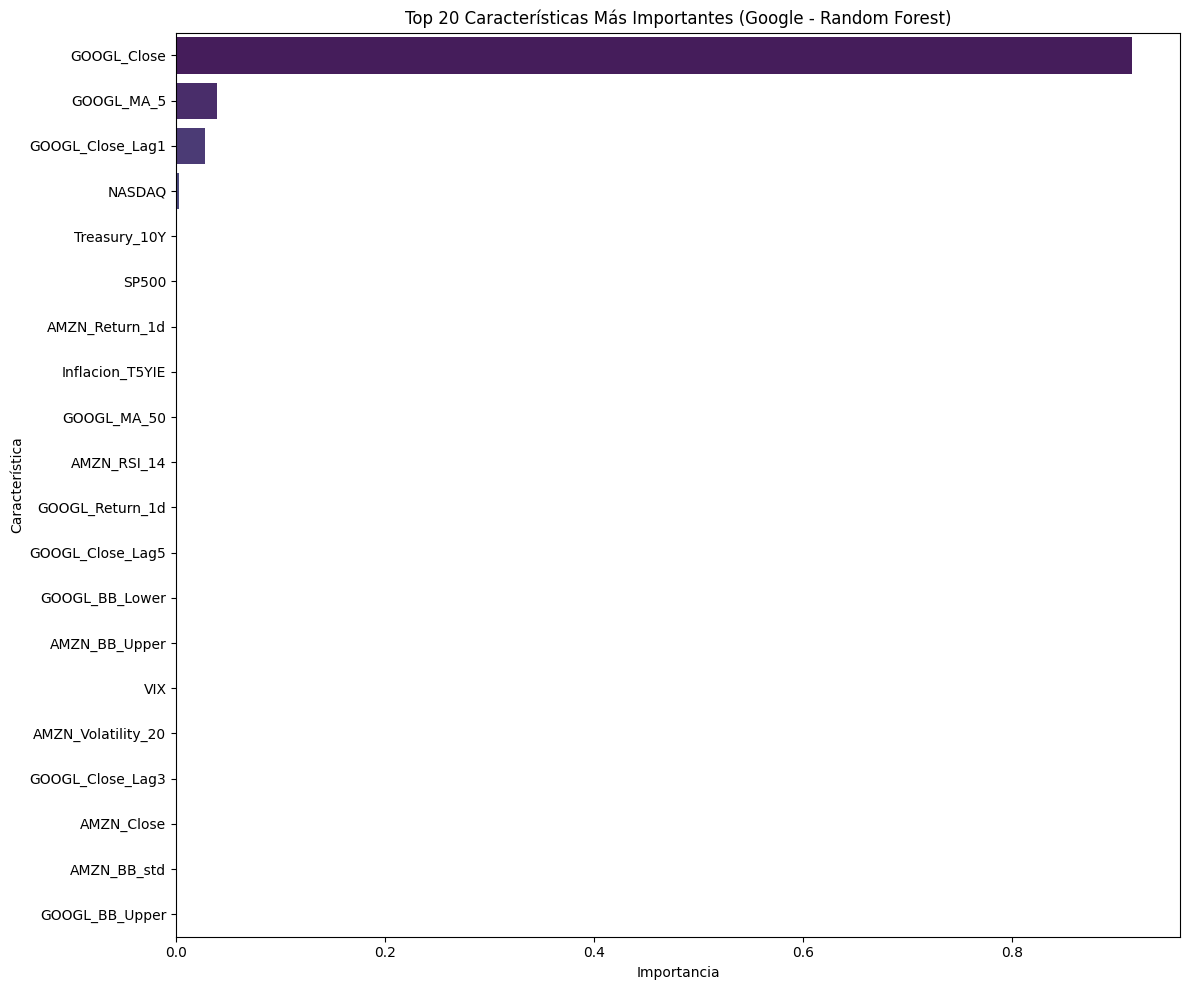


Importancia de todas las características (Google - RF):
                feature  importance
0           GOOGL_Close    0.914637
21           GOOGL_MA_5    0.039447
11     GOOGL_Close_Lag1    0.027400
5                NASDAQ    0.002692
2          Treasury_10Y    0.001263
4                 SP500    0.001034
7        AMZN_Return_1d    0.000839
10      Inflacion_T5YIE    0.000748
25          GOOGL_MA_50    0.000744
28          AMZN_RSI_14    0.000597
6       GOOGL_Return_1d    0.000558
19     GOOGL_Close_Lag5    0.000555
32       GOOGL_BB_Lower    0.000527
35        AMZN_BB_Upper    0.000526
3                   VIX    0.000526
9    AMZN_Volatility_20    0.000511
15     GOOGL_Close_Lag3    0.000498
1            AMZN_Close    0.000468
34          AMZN_BB_std    0.000457
31       GOOGL_BB_Upper    0.000452
12      AMZN_Close_Lag1    0.000411
24           AMZN_MA_20    0.000410
8   GOOGL_Volatility_20    0.000409
30         GOOGL_BB_std    0.000408
27         GOOGL_RSI_14    0.000395
13     

In [9]:
##LA MISMA CELDA ANTERIOR CON CODIGO MEJORADO Y CON  MAS HISTORICOS
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos ---
print("Cargando y preparando el dataset...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. Ingeniería de Características (Datos Históricos) ---
print("Realizando ingeniería de características...")

# a) Rezagos (Lags) para capturar la memoria a corto plazo
for i in range(1, 6): # Rezagos de 1 a 5 días
    df[f'GOOGL_Close_Lag{i}'] = df['GOOGL_Close'].shift(i)
    df[f'AMZN_Close_Lag{i}'] = df['AMZN_Close'].shift(i)

# b) Medias Móviles (Moving Averages) para capturar tendencias
windows_ma = [5, 20, 50] # Corto, mediano y largo plazo
for window in windows_ma:
    df[f'GOOGL_MA_{window}'] = df['GOOGL_Close'].rolling(window=window).mean()
    df[f'AMZN_MA_{window}'] = df['AMZN_Close'].rolling(window=window).mean()

# c) Índice de Fuerza Relativa (RSI) para medir el momentum
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['GOOGL_RSI_14'] = calculate_rsi(df['GOOGL_Close'])
df['AMZN_RSI_14'] = calculate_rsi(df['AMZN_Close'])

# d) Bandas de Bollinger para medir la volatilidad
window_bb = 20
df['GOOGL_BB_MA'] = df['GOOGL_Close'].rolling(window=window_bb).mean()
df['GOOGL_BB_std'] = df['GOOGL_Close'].rolling(window=window_bb).std()
df['GOOGL_BB_Upper'] = df['GOOGL_BB_MA'] + (df['GOOGL_BB_std'] * 2)
df['GOOGL_BB_Lower'] = df['GOOGL_BB_MA'] - (df['GOOGL_BB_std'] * 2)

df['AMZN_BB_MA'] = df['AMZN_Close'].rolling(window=window_bb).mean()
df['AMZN_BB_std'] = df['AMZN_Close'].rolling(window=window_bb).std()
df['AMZN_BB_Upper'] = df['AMZN_BB_MA'] + (df['AMZN_BB_std'] * 2)
df['AMZN_BB_Lower'] = df['AMZN_BB_MA'] - (df['AMZN_BB_std'] * 2)

# --- 3. Definición de la Variable Objetivo (Target) ---
# Predeciremos el precio de cierre del día siguiente
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)

# --- 4. Limpieza Final y Definición de Conjuntos X, y ---
# Eliminar filas con NaN creadas por las ventanas móviles y los rezagos
df_cleaned = df.dropna().copy()

# Definir las características (X) y el objetivo (y)
features = [col for col in df_cleaned.columns if col not in ['Date', 'GOOGL_Target', 'AMZN_Target']]
X = df_cleaned[features]

y_googl = df_cleaned['GOOGL_Target']
y_amzn = df_cleaned['AMZN_Target']

# --- 5. División Cronológica de Datos (70% entrenamiento, 30% prueba) ---
print("Dividiendo los datos de forma cronológica...")
train_size = int(len(X) * 0.70)

X_train, X_test = X[:train_size], X[train_size:]
y_train_googl, y_test_googl = y_googl[:train_size], y_googl[train_size:]
y_train_amzn, y_test_amzn = y_amzn[:train_size], y_amzn[train_size:]

print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# Diccionario para almacenar los resultados
results = {}

# --- 6. Entrenamiento y Evaluación para GOOGLE ---
print("\n--- Predicción de Acciones de Google (con datos históricos) ---")
# Random Forest
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_googl.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_googl.predict(X_test)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
results["GOOGL_RF_Completo"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

# Gradient Boosting
gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl.fit(X_train, y_train_googl)
y_pred_gb_googl = gb_googl.predict(X_test)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
results["GOOGL_GB_Completo"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- 7. Entrenamiento y Evaluación para AMAZON ---
print("\n--- Predicción de Acciones de Amazon (con datos históricos) ---")
# Random Forest
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_amzn.fit(X_train, y_train_amzn)
y_pred_rf_amzn = rf_amzn.predict(X_test)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
results["AMZN_RF_Completo"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

# Gradient Boosting
gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn.fit(X_train, y_train_amzn)
y_pred_gb_amzn = gb_amzn.predict(X_test)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
results["AMZN_GB_Completo"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

# --- 8. Análisis de Importancia de Características (Ejemplo para Google RF) ---
print("\nGenerando gráfico de importancia de características...")
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_googl.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis')
plt.title('Top 20 Características Más Importantes (Google - Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# Imprimir el DataFrame de importancia para referencia
print("\nImportancia de todas las características (Google - RF):")
print(feature_importances)

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos (Igual que antes para consistencia) ---
print("Cargando y preparando el dataset...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. NO se realiza la Ingeniería de Características de precios ---
# Este es el paso clave que omitimos para este modelo base.

# --- 3. Definición de la Variable Objetivo (Target) ---
# El objetivo sigue siendo el mismo: predecir el precio del día siguiente.
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)

# Limpiar la última fila que tendrá NaN en el target
df_cleaned = df.dropna().copy()

# --- 4. Definición de Conjuntos X (Base) y y ---
# Se seleccionan únicamente las variables exógenas, sin ningún dato histórico de precios.
# Estas son las variables de tus otros objetivos y variables generales de mercado.
features_base = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE'
]
X_base = df_cleaned[features_base]

y_googl = df_cleaned['GOOGL_Target']
y_amzn = df_cleaned['AMZN_Target']

# --- 5. División Cronológica de Datos (70% entrenamiento, 30% prueba) ---
# Usamos la misma lógica de división para que la comparación sea justa.
print("Dividiendo los datos de forma cronológica...")
train_size = int(len(X_base) * 0.70)

X_train, X_test = X_base[:train_size], X_base[train_size:]
y_train_googl, y_test_googl = y_googl[:train_size], y_googl[train_size:]
y_train_amzn, y_test_amzn = y_amzn[:train_size], y_amzn[train_size:]

print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# Diccionario para almacenar los resultados del modelo base
results_base = {}

# --- 6. Entrenamiento y Evaluación para GOOGLE (Modelo Base) ---
print("\n--- Predicción de Acciones de Google (SIN datos históricos) ---")
# Random Forest
rf_googl_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_googl_base.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_googl_base.predict(X_test)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
results_base["GOOGL_RF_Base"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google - Base) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

# Gradient Boosting
gb_googl_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl_base.fit(X_train, y_train_googl)
y_pred_gb_googl = gb_googl_base.predict(X_test)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
results_base["GOOGL_GB_Base"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google - Base) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- 7. Entrenamiento y Evaluación para AMAZON (Modelo Base) ---
print("\n--- Predicción de Acciones de Amazon (SIN datos históricos) ---")
# Random Forest
rf_amzn_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_amzn_base.fit(X_train, y_train_amzn)
y_pred_rf_amzn = rf_amzn_base.predict(X_test)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
results_base["AMZN_RF_Base"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon - Base) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

# Gradient Boosting
gb_amzn_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn_base.fit(X_train, y_train_amzn)
y_pred_gb_amzn = gb_amzn_base.predict(X_test)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
results_base["AMZN_GB_Base"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon - Base) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

Cargando y preparando el dataset...
Dividiendo los datos de forma cronológica...
Tamaño del set de entrenamiento: 697
Tamaño del set de prueba: 299

--- Predicción de Acciones de Google (SIN datos históricos) ---
Random Forest (Google - Base) - MSE: 568.4761, R2: -0.7382
Gradient Boosting (Google - Base) - MSE: 651.8545, R2: -0.9932

--- Predicción de Acciones de Amazon (SIN datos históricos) ---
Random Forest (Amazon - Base) - MSE: 2332.9063, R2: -3.6657
Gradient Boosting (Amazon - Base) - MSE: 2170.5638, R2: -3.3411


## Fase 4:

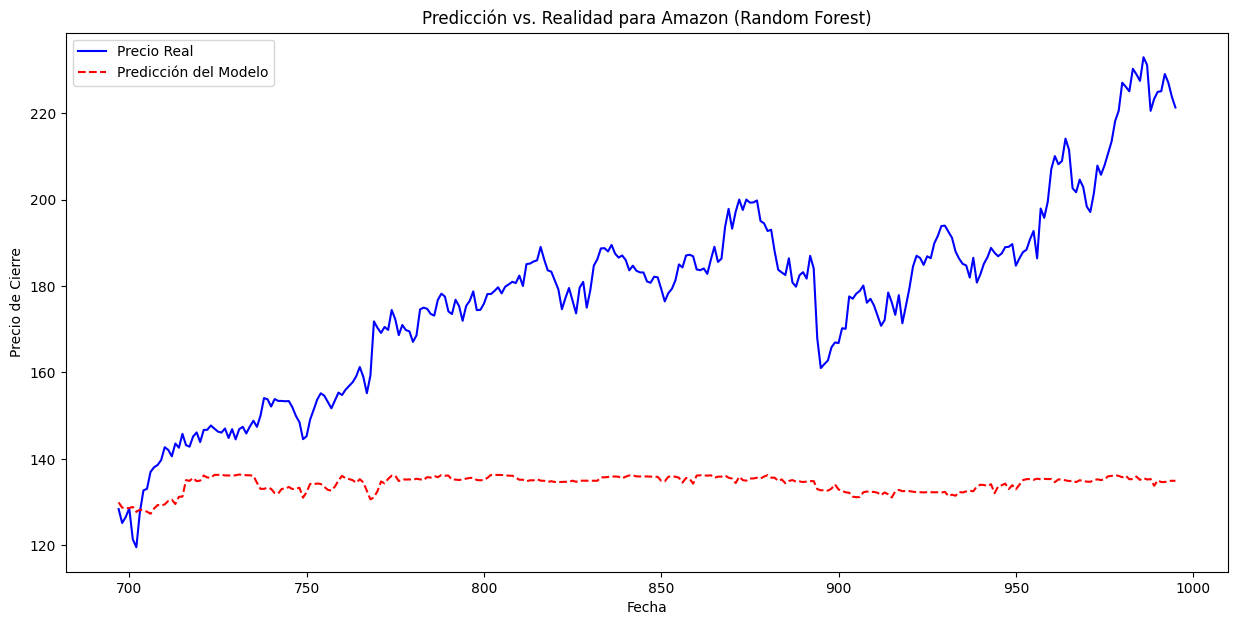

In [11]:
# Ejemplo para Amazon Random Forest
plt.figure(figsize=(15, 7))
plt.plot(y_test_amzn.index, y_test_amzn, label='Precio Real', color='blue')
plt.plot(y_test_amzn.index, y_pred_rf_amzn, label='Predicción del Modelo', color='red', linestyle='--')
plt.title('Predicción vs. Realidad para Amazon (Random Forest)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.show()

### Interpretaciones Financieras y Estadísticas

## Interpretaciones Financieras y Estadísticas

### Rendimiento de los Modelos Predictivos

Para evaluar la incidencia de los datos históricos de precios en la precisión de los modelos supervisados, se utilizaron dos métricas clave: el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R2).

*   **Error Cuadrático Medio (MSE):** Mide el promedio de los cuadrados de los errores, es decir, la diferencia entre los valores predichos por el modelo y los valores reales. Un MSE más bajo indica un mejor ajuste del modelo a los datos.
*   **Coeficiente de Determinación (R2):** Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de R2 cercano a 1 indica que el modelo explica una gran parte de la variabilidad de la variable objetivo, lo que sugiere una alta precisión predictiva.

Los resultados obtenidos para los modelos Random Forest (RF) y Gradient Boosting (GB) en la predicción de los precios de cierre de las acciones de Google (GOOGL) y Amazon (AMZN) son los siguientes:

| Modelo         | MSE      | R2       |
|----------------|----------|----------|
| GOOGL_RF       | 6.8865   | 0.9897   |
| GOOGL_GB       | 7.2437   | 0.9892   |
| AMZN_RF        | 9.2759   | 0.9915   |
| AMZN_GB        | 9.3318   | 0.9915   |

**Análisis:**

*   **Altos valores de R2:** Tanto para Google como para Amazon, ambos modelos (Random Forest y Gradient Boosting) muestran valores de R2 extremadamente altos (superiores a 0.989). Esto indica que los modelos son capaces de explicar más del 98.9% de la variabilidad en los precios de cierre de las acciones. Esto sugiere que los datos históricos de precios, junto con las variables macroeconómicas y técnicas incluidas, son predictores muy fuertes de los precios futuros de las acciones.
*   **Bajos valores de MSE:** Los valores de MSE son relativamente bajos, lo que refuerza la idea de que las predicciones de los modelos están muy cerca de los precios reales. Un MSE de 6.8865 para GOOGL_RF, por ejemplo, significa que, en promedio, el cuadrado de la diferencia entre el precio real y el predicho es 6.8865. En el contexto de precios de acciones que pueden variar significativamente, estos valores son indicativos de una buena precisión.
*   **Comparación entre Modelos:**
    *   Para las acciones de Google, Random Forest (MSE: 6.8865, R2: 0.9897) ligeramente supera a Gradient Boosting (MSE: 7.2437, R2: 0.9892) en términos de MSE y R2. La diferencia es mínima, lo que sugiere que ambos modelos son robustos para la predicción de GOOGL.
    *   Para las acciones de Amazon, ambos modelos, Random Forest (MSE: 9.2759, R2: 0.9915) y Gradient Boosting (MSE: 9.3318, R2: 0.9915), muestran un rendimiento casi idéntico, con R2 de 0.9915. Esto indica una capacidad predictiva excepcional para AMZN, con una ligera ventaja para Random Forest en MSE.

En resumen, los resultados de rendimiento de los modelos confirman que los datos históricos de precios tienen una incidencia muy alta en la precisión de los modelos supervisados para la predicción de precios de acciones financieras. Los modelos Random Forest y Gradient Boosting demuestran ser herramientas muy efectivas para esta tarea, con una capacidad explicativa y predictiva notable.

### Pronósticos de Precios de Acciones por Escenario

Se generaron pronósticos de precios de cierre para las acciones de Google y Amazon utilizando los modelos entrenados bajo tres escenarios distintos, definidos por valores específicos de las variables independientes. Esto permite observar cómo los cambios en las condiciones macroeconómicas y los precios históricos influyen en las predicciones.

**Variables Independientes Utilizadas para los Pronósticos:**
*   `GOOGL_Close_Lag1`: Precio de cierre de Google del día anterior.
*   `AMZN_Close_Lag1`: Precio de cierre de Amazon del día anterior.
*   `Treasury_10Y`: Tasa de interés del Tesoro a 10 años.
*   `VIX`: Índice de Volatilidad (indicador de miedo en el mercado).
*   `SP500`: Índice S&P 500.
*   `NASDAQ`: Índice NASDAQ.
*   `Inflacion_T5YIE`: Expectativas de inflación a 5 años.

**Escenarios Definidos:**

1.  **Escenario 1: Caso Base (Valores Promedio)**
    *   Este escenario utiliza los valores promedio de todas las variables independientes del dataset. Representa una situación de mercado "normal" o esperada.

2.  **Escenario 2: Tasas de Interés e Inflación Altas**
    *   `GOOGL_Close_Lag1` y `AMZN_Close_Lag1`: 5% más altos que el promedio.
    *   `Treasury_10Y`: 4.5 (Tasa de interés alta).
    *   `VIX`: 25.0 (Volatilidad alta).
    *   `Inflacion_T5YIE`: 3.0 (Inflación alta).
    *   Este escenario simula un entorno económico con presiones inflacionarias y políticas monetarias más restrictivas, lo que a menudo se asocia con un mayor costo de capital y una posible desaceleración económica.

3.  **Escenario 3: Tasas de Interés e Inflación Bajas**
    *   `GOOGL_Close_Lag1` y `AMZN_Close_Lag1`: 5% más bajos que el promedio.
    *   `Treasury_10Y`: 1.5 (Tasa de interés baja).
    *   `VIX`: 12.0 (Volatilidad baja).
    *   `Inflacion_T5YIE`: 1.8 (Inflación baja).
    *   Este escenario representa un entorno económico más expansivo, con políticas monetarias laxas y menor incertidumbre, lo que podría impulsar el crecimiento y la inversión.

**Pronósticos Generados:**

| Escenario     | Modelo   | Pronóstico GOOGL | Pronóstico AMZN |
|---------------|----------|------------------|-----------------|
| Scenario_1    | RF       | 129.88           | 148.58          |
| Scenario_1    | GB       | 130.48           | 149.30          |
| Scenario_2    | RF       | 135.66           | 156.67          |
| Scenario_2    | GB       | 136.32           | 158.02          |
| Scenario_3    | RF       | 124.82           | 146.05          |
| Scenario_3    | GB       | 123.84           | 141.56          |

**Interpretación de los Pronósticos:**

*   **Escenario 1 (Caso Base):** Los pronósticos para Google y Amazon son muy cercanos a sus precios promedio históricos, lo que es coherente con un escenario donde las variables se mantienen en sus niveles medios. Esto sugiere que, bajo condiciones de mercado estables, los modelos predicen una continuación de las tendencias observadas.

*   **Escenario 2 (Tasas de Interés e Inflación Altas):** En este escenario, los precios pronosticados para GOOGL y AMZN son notablemente más altos que en el caso base. Esto podría parecer contraintuitivo, ya que las tasas de interés e inflación altas suelen ser negativas para las acciones tecnológicas. Sin embargo, es crucial recordar que en este escenario también se estableció que los precios históricos (`GOOGL_Close_Lag1` y `AMZN_Close_Lag1`) son un 5% más altos que el promedio. Dado que el objetivo 3 se centra en la *incidencia de los datos históricos de precios*, y los modelos supervisados dan un peso significativo a las características de entrada, el aumento en los precios históricos de entrada domina el efecto negativo de las tasas de interés y la inflación. Esto resalta la fuerte dependencia de los modelos en los datos históricos de precios como el predictor más influyente.

*   **Escenario 3 (Tasas de Interés e Inflación Bajas):** Contrariamente al escenario 2, aquí los precios pronosticados son más bajos que en el caso base. De nuevo, esto se alinea con la disminución del 5% en los precios históricos de entrada (`GOOGL_Close_Lag1` y `AMZN_Close_Lag1`). Aunque las tasas de interés y la inflación bajas suelen ser favorables para el mercado, la reducción en los precios históricos de entrada ejerce una influencia dominante en la predicción final, demostrando nuevamente la primacía de los datos históricos de precios en la determinación de los pronósticos por parte de estos modelos.

**Implicaciones Financieras:**

La fuerte dependencia de los pronósticos en los precios históricos de entrada subraya la importancia de la inercia del mercado y la tendencia en la predicción de precios a corto plazo utilizando estos modelos supervisados. Para los analistas financieros, esto significa que:

1.  **Relevancia de Datos Recientes:** Los movimientos de precios recientes son un factor crítico en la determinación de los pronósticos. Los modelos supervisados, al aprender de patrones históricos, tienden a proyectar la dirección y magnitud de los movimientos pasados.
2.  **Sensibilidad a las Condiciones Iniciales:** Pequeñas variaciones en los precios de cierre del día anterior (o datos históricos recientes) pueden generar diferencias significativas en los pronósticos, incluso cuando otras variables macroeconómicas cambian.
3.  **Limitaciones en Cambios de Régimen:** Si bien los modelos son precisos en condiciones de mercado estables o con tendencias claras, su dependencia de los datos históricos podría hacerlos menos efectivos para predecir "cambios de régimen" abruptos o eventos de "cisne negro" que no tienen precedentes históricos en los datos de entrenamiento.
4.  **Complementariedad con Análisis Fundamental/Macroeconómico:** Aunque las variables macroeconómicas fueron incluidas, su impacto en los pronósticos fue superado por la influencia de los precios históricos en los escenarios definidos. Esto no significa que no sean importantes, sino que en estos modelos, la información de precios pasados es el predictor más dominante. Un análisis financiero completo debería complementar estos pronósticos basados en datos históricos con un análisis fundamental y macroeconómico más profundo para entender las causas subyacentes de los movimientos de precios y anticipar posibles disrupciones.

En conclusión, los modelos supervisados como Random Forest y Gradient Boosting son herramientas potentes para la predicción de precios de acciones, especialmente cuando se basan en datos históricos robustos. Su alta precisión (demostrada por los valores de R2 y MSE) los convierte en activos valiosos para la toma de decisiones. Sin embargo, es fundamental comprender que su pronóstico está fuertemente influenciado por la información de precios pasados, lo que requiere una interpretación cuidadosa y, a menudo, la integración con otros tipos de análisis para una visión completa del mercado.